## 첫번째 모델

In [2]:
import tensorflow as tf
tf.keras.utils.set_random_seed(42)

In [3]:
from tensorflow.keras.datasets import imdb

(train_input, train_target), (test_input, test_taraget) = imdb.load_data(num_words=500)

In [4]:
train_input.shape, train_target.shape, test_input.shape, test_taraget.shape

((25000,), (25000,), (25000,), (25000,))

In [8]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen = 100)

In [9]:
train_seq.shape

(25000, 100)

In [15]:
from tensorflow import keras

model = keras.Sequential()
model.add(keras.layers.Input(shape = (100,)))
model.add(keras.layers.Embedding(500,16))
model.add(keras.layers.LSTM(8))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 16)           8000      
                                                                 
 lstm_3 (LSTM)               (None, 8)                 800       
                                                                 
 dense (Dense)               (None, 1)                 9         
                                                                 
Total params: 8,809
Trainable params: 8,809
Non-trainable params: 0
_________________________________________________________________


In [17]:
optimizer = keras.optimizers.RMSprop(learning_rate = 1e-4)
model.compile(optimizer = optimizer, loss= 'binary_crossentropy', metrics = ['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('output/best-lstm-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience = 3, restore_best_weights= True)

history = model.fit(
    train_seq, train_target,
    epochs = 100,
    batch_size = 64,
    validation_split= 0.2,
    callbacks = [checkpoint_cb, early_stopping_cb]
)

Epoch 1/100
313/313 [==============================] - 485s 11ms/step - loss: 0.6925 - accuracy: 0.5385 - val_loss: 0.6918 - val_accuracy: 0.5772
Epoch 2/100
313/313 [==============================] - 3s 10ms/step - loss: 0.6904 - accuracy: 0.6044 - val_loss: 0.6890 - val_accuracy: 0.6186
Epoch 3/100
313/313 [==============================] - 3s 10ms/step - loss: 0.6847 - accuracy: 0.6455 - val_loss: 0.6797 - val_accuracy: 0.6640
Epoch 4/100
313/313 [==============================] - 3s 10ms/step - loss: 0.6560 - accuracy: 0.7076 - val_loss: 0.6169 - val_accuracy: 0.7266
Epoch 5/100
313/313 [==============================] - 3s 10ms/step - loss: 0.5981 - accuracy: 0.7233 - val_loss: 0.5863 - val_accuracy: 0.7262
Epoch 6/100
313/313 [==============================] - 3s 10ms/step - loss: 0.5717 - accuracy: 0.7358 - val_loss: 0.5635 - val_accuracy: 0.7434
Epoch 7/100
313/313 [==============================] - 3s 10ms/step - loss: 0.5486 - accuracy: 0.7523 - val_loss: 0.5472 - val_accurac

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

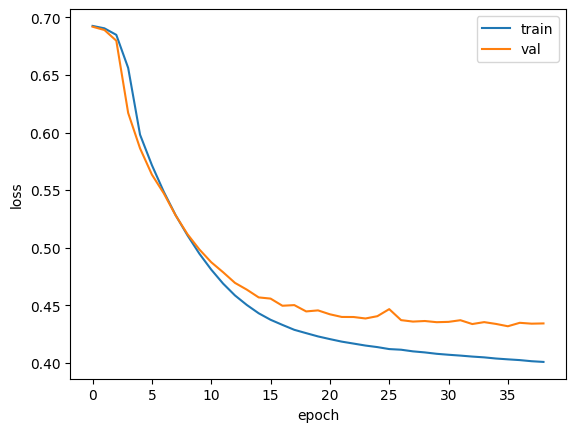

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','val'])
plt.show()

## 두번째 모델

In [20]:
from tensorflow.keras.datasets import imdb
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words = 1000)

In [26]:
import numpy as np

# 각 샘플(리뷰) 길이
train_lens = np.array([len(x) for x in X_train])
test_lens  = np.array([len(x) for x in X_test])

def summarize(name, lens):
    print(f"\n[{name}]")
    print("count:", len(lens))
    print("min  :", lens.min())
    print("max  :", lens.max())
    print("mean :", lens.mean().round(2))
    print("median:", np.median(lens))
    for p in [90, 95, 98, 99]:
        print(f"p{p:02d} :", int(np.percentile(lens, p)))

summarize("train", train_lens)
summarize("test", test_lens)



[train]
count: 25000
min  : 11
max  : 2494
mean : 238.71
median: 178.0
p90 : 467
p95 : 610
p98 : 799
p99 : 926

[test]
count: 25000
min  : 7
max  : 2315
mean : 230.8
median: 174.0
p90 : 446
p95 : 586
p98 : 771
p99 : 902


In [27]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

maxlen = 467
X_train_pad = pad_sequences(X_train, maxlen=maxlen, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test,  maxlen=maxlen, padding="post", truncating="post")

In [31]:
from tensorflow import keras

model_dropout = keras.models.Sequential([
    keras.layers.Input(shape=(maxlen,)),
    keras.layers.Embedding(input_dim=1000, output_dim=128),

    keras.layers.LSTM(256, return_sequences=True),
    keras.layers.Dropout(0.3),

    keras.layers.LSTM(256),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(1, activation="sigmoid"),
])

In [35]:
optimizer = keras.optimizers.Adam(learning_rate = 1e-4)
model_dropout.compile(optimizer = optimizer, loss= 'binary_crossentropy', metrics = ['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('output/best-dropout-lstm-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience = 10, restore_best_weights= True)

history_dropout = model_dropout.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/100
313/313 [==============================] - 37s 112ms/step - loss: 0.6933 - accuracy: 0.5041 - val_loss: 0.6932 - val_accuracy: 0.5016
Epoch 2/100
313/313 [==============================] - 34s 109ms/step - loss: 0.6925 - accuracy: 0.5053 - val_loss: 0.6936 - val_accuracy: 0.5012
Epoch 3/100
313/313 [==============================] - 35s 112ms/step - loss: 0.6933 - accuracy: 0.5071 - val_loss: 0.6925 - val_accuracy: 0.5130
Epoch 4/100
313/313 [==============================] - 34s 108ms/step - loss: 0.6900 - accuracy: 0.5181 - val_loss: 0.6915 - val_accuracy: 0.5204
Epoch 5/100
313/313 [==============================] - 35s 111ms/step - loss: 0.7022 - accuracy: 0.5161 - val_loss: 0.6812 - val_accuracy: 0.5292
Epoch 6/100
313/313 [==============================] - 34s 109ms/step - loss: 0.6874 - accuracy: 0.5253 - val_loss: 0.6845 - val_accuracy: 0.5062
Epoch 7/100
313/313 [==============================] - 35s 112ms/step - loss: 0.6865 - accuracy: 0.5235 - val_loss: 0.6830 -

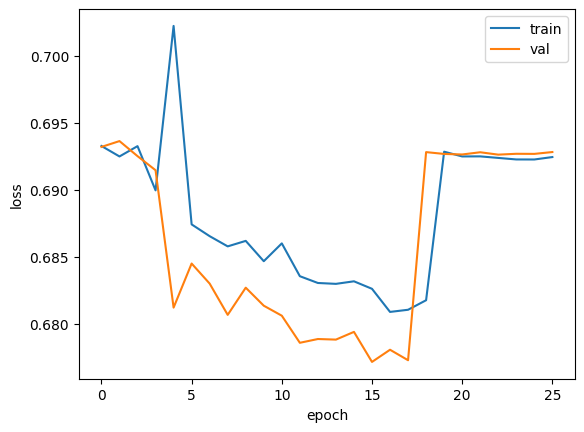

In [36]:
plt.plot(history_dropout.history['loss'])
plt.plot(history_dropout.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','val'])
plt.show()

## 비트코인 데이터

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

In [2]:
data = pd.read_csv('data/BTC_USD_2019-02-28_2020-02-27-CoinDesk.csv')

In [3]:
print(data.shape)
print(data.info())
print(data.head())

(365, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Currency             365 non-null    object 
 1   Date                 365 non-null    object 
 2   Closing Price (USD)  365 non-null    float64
 3   24h Open (USD)       365 non-null    float64
 4   24h High (USD)       365 non-null    float64
 5   24h Low (USD)        365 non-null    float64
dtypes: float64(4), object(2)
memory usage: 17.2+ KB
None
  Currency        Date  Closing Price (USD)  24h Open (USD)  24h High (USD)  \
0      BTC  2019-02-28          3772.936335     3796.637284     3824.165879   
1      BTC  2019-03-01          3799.678543     3773.441461     3879.231185   
2      BTC  2019-03-02          3811.611979     3799.367026     3840.044823   
3      BTC  2019-03-03          3804.419170     3806.691513     3819.194356   
4      BTC  2019-03-04          37

In [4]:
data['Closing Price (USD)'].shape

(365,)

In [5]:
seq = data[['Closing Price (USD)']].to_numpy()
seq.shape

(365, 1)

In [6]:
seq[:5]

array([[3772.93633533],
       [3799.67854295],
       [3811.61197937],
       [3804.41917011],
       [3782.66410112]])

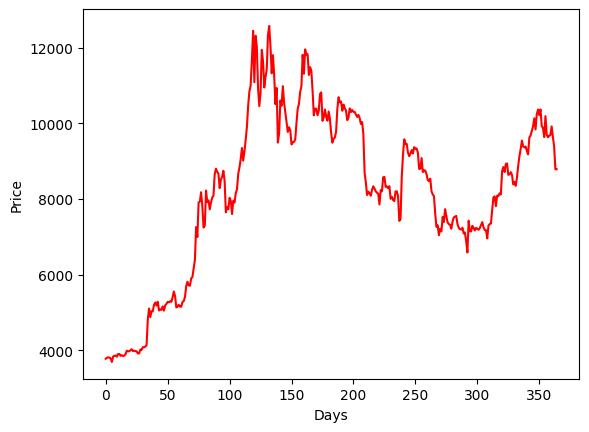

In [7]:
plt.plot(seq, color = 'red')
plt.xlabel('Days')
plt.ylabel('Price')
plt.show()

In [8]:
def seq2dataset(seq,window,horizon):
    X=[]; Y=[]
    for i in range(len(seq)-(window+horizon)+1):
        x=seq[i:(i+window)]
        y=(seq[i+window+horizon-1])
        X.append(x); Y.append(y)
    return np.array(X), np.array(Y)

In [9]:
w = 7
h = 1

X,y = seq2dataset(seq,w,h)

In [10]:
X.shape, y.shape

((358, 7, 1), (358, 1))

In [11]:
# y[0]의 값이 x[1]의 마지막 값과 똑같이면 된다!
print(X[0], y[0])
print(X[1])

[[3772.93633533]
 [3799.67854295]
 [3811.61197937]
 [3804.41917011]
 [3782.66410112]
 [3689.86289319]
 [3832.08088473]] [3848.95636968]
[[3799.67854295]
 [3811.61197937]
 [3804.41917011]
 [3782.66410112]
 [3689.86289319]
 [3832.08088473]
 [3848.95636968]]


In [12]:
split = int(len(X)* 0.7)

In [13]:
split

250

In [34]:
X_train = X[0:split]
y_train = y[0:split]
X_test = X[split:]
y_test = y[split:]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((250, 7, 1), (250, 1), (108, 7, 1), (108, 1))

In [33]:
# lstm 128, relu
input_shape = X_train[0].shape

model_lstm = keras.Sequential()
model_lstm.add(keras.layers.Input(shape = input_shape))
model_lstm.add(keras.layers.LSTM(128, return_sequences=True))
model_lstm.add(keras.layers.LSTM(128))
model_lstm.add(keras.layers.Dense(64, activation= 'relu'))
model_lstm.add(keras.layers.Dense(1, activation = 'linear'))
model_lstm.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 7, 128)            66560     
                                                                 
 lstm_5 (LSTM)               (None, 128)               131584    
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dense_5 (Dense)             (None, 1)                 65        
                                                                 
Total params: 206,465
Trainable params: 206,465
Non-trainable params: 0
_________________________________________________________________


In [35]:
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
model_lstm.compile(loss = 'mae', optimizer = optimizer, metrics = ['mae'])

model_lstm.fit(X_train, y_train, epochs = 200, batch_size = 1, validation_data = [X_test, y_test])


Epoch 1/200
250/250 [==============================] - 3s 6ms/step - loss: 8271.2002 - mae: 8271.2002 - val_loss: 8270.4707 - val_mae: 8270.4707
Epoch 2/200
250/250 [==============================] - 1s 3ms/step - loss: 8249.8174 - mae: 8249.8174 - val_loss: 8249.0742 - val_mae: 8249.0742
Epoch 3/200
250/250 [==============================] - 1s 3ms/step - loss: 8226.1348 - mae: 8226.1348 - val_loss: 8222.8760 - val_mae: 8222.8760
Epoch 4/200
250/250 [==============================] - 1s 4ms/step - loss: 8197.2627 - mae: 8197.2627 - val_loss: 8191.3003 - val_mae: 8191.3003
Epoch 5/200
250/250 [==============================] - 1s 4ms/step - loss: 8163.0269 - mae: 8163.0269 - val_loss: 8154.4023 - val_mae: 8154.4023
Epoch 6/200
250/250 [==============================] - 1s 4ms/step - loss: 8123.5518 - mae: 8123.5518 - val_loss: 8112.3691 - val_mae: 8112.3691
Epoch 7/200
250/250 [==============================] - 1s 4ms/step - loss: 8079.0596 - mae: 8079.0596 - val_loss: 8065.4224 - val_

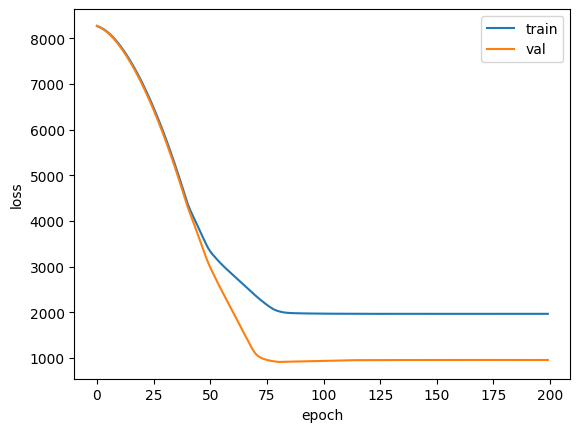

In [41]:
plt.plot(model_lstm.history.history['loss'])
plt.plot(model_lstm.history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','val'])
plt.show()

In [ ]:
# # lstm 128, relu
# input_shape = X_train[0].shape

# model = keras.Sequential()
# model.add(keras.layers.Input(shape = input_shape))
# model.add(keras.layers.LSTM(128, return_sequences=True))
# model.add(keras.layers.LSTM(128))
# model.add(keras.layers.Dense(64, activation= 'relu'))
# model.add(keras.layers.Dense(1, activation = 'linear'))

# optimizer = keras.optimizers.Adam(learning_rate=1e-4)
# model.compile(loss = 'mae', optimizer = optimizer, metrics = ['mae'])
# checkpoint_cb = keras.callbacks.ModelCheckpoint('output/best-linear-lstm-model.keras', save_best_only=True)
# early_stopping_cb = keras.callbacks.EarlyStopping(patience = 10, restore_best_weights= True)

# model.fit(X_train, y_train, epochs = 200, batch_size = 1, validation_data = [X_test, y_test])

# plt.plot(model.history.history['loss'])
# plt.plot(model.history.history['val_loss'])
# plt.xlabel('epoch')
# plt.ylabel('loss')
# plt.legend(['train','val'])
# plt.show()

## MAE (Mean Absolute Error, 평균 절대값 오차)

- 정의: 예측값과 실제값의 **절대 오차**를 평균낸 값  
- 수식: **MAE = (1/n) * Σ |y - ŷ|**

### 간단 예시
- 실제값(y):  [10, 12, 14]
- 예측값(ŷ): [ 9, 13, 15]

절대오차: |10-9|=1, |12-13|=1, |14-15|=1  
➡️ **MAE = (1+1+1) / 3 = 1.0**



## MAPE (Mean Absolute Percentage Error, 평균 절대값 백분율 오차)

- 정의: 오차를 실제값 대비 **백분율(%)**로 바꾼 뒤 평균낸 값  
- 수식: **MAPE = (100/n) * Σ ( |y - ŷ| / |y| )**

### 간단 예시
- 실제값(y):  [100, 200, 300]
- 예측값(ŷ): [110, 180, 330]

각 항의 백분율 오차:
- |100-110|/100 = 0.10 → 10%
- |200-180|/200 = 0.10 → 10%
- |300-330|/300 = 0.10 → 10%

➡️ **MAPE = (10% + 10% + 10%) / 3 = 10%**


In [ ]:
ev = model_lstm.evaluate(X_test, y_test)

4/4 [==============================] - 0s 5ms/step - loss: 959.1490 - mae: 959.1490


In [21]:
ev

[959.1489868164062, 959.1489868164062]

In [ ]:
pred = model_lstm.predict(X_test)

4/4 [==============================] - 0s 4ms/step


In [23]:
sum(abs((y_test- pred)/y_test)/len(X_test))

array([0.12019579])

In [48]:
model_lstm.history.history

{'loss': [8271.2001953125,
  8249.8173828125,
  8226.134765625,
  8197.2626953125,
  8163.02685546875,
  8123.5517578125,
  8079.0595703125,
  8029.75048828125,
  7975.86865234375,
  7917.6044921875,
  7855.13134765625,
  7788.60986328125,
  7718.17626953125,
  7643.93798828125,
  7566.00146484375,
  7484.44921875,
  7399.3427734375,
  7310.75830078125,
  7218.73291015625,
  7123.31689453125,
  7024.5390625,
  6922.43896484375,
  6817.03759765625,
  6708.35693359375,
  6596.42041015625,
  6481.24365234375,
  6362.84228515625,
  6241.2275390625,
  6116.412109375,
  5988.40771484375,
  5857.22119140625,
  5722.859375,
  5585.33447265625,
  5444.6484375,
  5300.8134765625,
  5153.83447265625,
  5003.7138671875,
  4850.45947265625,
  4694.07470703125,
  4534.564453125,
  4381.720703125,
  4256.412109375,
  4149.3525390625,
  4045.322021484375,
  3940.1083984375,
  3833.599365234375,
  3725.822998046875,
  3617.680908203125,
  3511.661865234375,
  3413.41357421875,
  3334.1123046875,
  3271

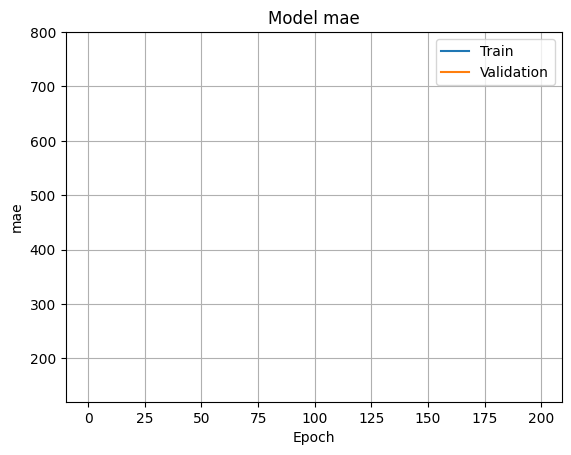

In [49]:
plt.plot(model_lstm.history.history['mae'])
plt.plot(model_lstm.history.history['val_mae'])
plt.title('Model mae')
plt.ylabel('mae')
plt.xlabel('Epoch')
plt.ylim([120,800])
plt.legend(['Train','Validation'], loc = 'best')
plt.grid()
plt.show()

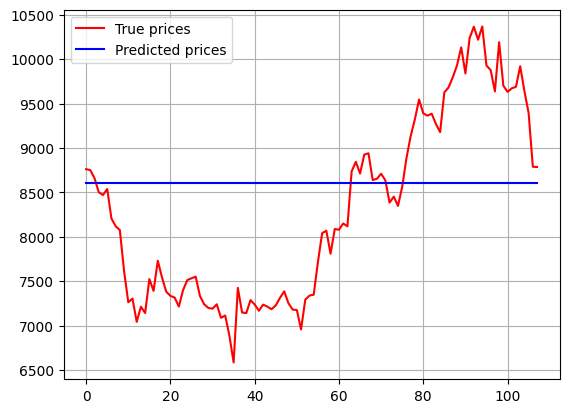

In [50]:
x_range=range(len(y_test))
plt.plot(x_range,y_test[x_range], color='red')
plt.plot(x_range,pred[x_range], color='blue')
plt.legend(['True prices','Predicted prices'], loc='best')
plt.grid()
plt.show()